In [1]:
import pandas as pd

path = "/scratch/joshi.shreyas/LSWMD.pkl"
df = pd.read_pickle(path)

print(df.shape)
print(df.columns)

(811457, 6)
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [2]:
df = df.rename(columns={'trianTestLabel': 'trainTestLabel'})

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()
print(df.dtypes)
print()
print(df.head(3))

Shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trainTestLabel', 'failureType']

waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trainTestLabel     object
failureType        object
dtype: object

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trainTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  


In [3]:
# Cell 2: Unwrap nested labels + check uniques
import numpy as np

def unwrap(x):
    """Flattens things like [['Training']] or [['none']] down to a plain string,
    and returns 'MISSING' for genuinely empty entries."""
    arr = np.array(x)
    if arr.size == 0:
        return 'MISSING'
    return str(arr.flatten()[0])

df['trainTestLabel_clean'] = df['trainTestLabel'].apply(unwrap)
df['failureType_clean'] = df['failureType'].apply(unwrap)

print("TrainTestLabel unique values")
print(df['trainTestLabel_clean'].value_counts(dropna=False))
print()
print("FailureType unique values ")
print(df['failureType_clean'].value_counts(dropna=False))

TrainTestLabel unique values
MISSING     638507
Test        118595
Training     54355
Name: trainTestLabel_clean, dtype: int64

FailureType unique values 
MISSING      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: failureType_clean, dtype: int64


In [4]:
# Cell 3 (bulletproof version): manual counting, no pandas reshape functions at all
labeled_df = df[df['failureType_clean'] != 'MISSING'].copy()

classes = sorted(labeled_df['failureType_clean'].unique())
splits = sorted(labeled_df['trainTestLabel_clean'].unique())

print(f"{'Class':<12}", end='')
for s in splits:
    print(f"{s:>12}", end='')
print()

for c in classes:
    print(f"{c:<12}", end='')
    for s in splits:
        count = ((labeled_df['failureType_clean'] == c) & (labeled_df['trainTestLabel_clean'] == s)).sum()
        print(f"{count:>12}", end='')
    print()

Class               Test    Training
Center               832        3462
Donut                146         409
Edge-Loc            2772        2417
Edge-Ring           1126        8554
Loc                 1973        1620
Near-full             95          54
Random               257         609
Scratch              693         500
none              110701       36730


In [5]:
# Cell 4: Wafer map dimension variability
shapes = df['waferMap'].apply(lambda x: np.array(x).shape)
shape_counts = shapes.value_counts()

print("Number of distinct (rows, cols) shapes:", shape_counts.shape[0])
print()
print("Top 15 most common shapes:")
print(shape_counts.head(15))

Number of distinct (rows, cols) shapes: 632

Top 15 most common shapes:
(32, 29)    108687
(25, 27)     64083
(49, 39)     39323
(26, 26)     30078
(30, 34)     29513
(33, 33)     23886
(33, 29)     20276
(39, 37)     15327
(52, 59)     14812
(31, 31)     14569
(39, 31)     13562
(29, 26)     13247
(27, 25)     12655
(64, 71)     11692
(31, 28)     10788
Name: waferMap, dtype: int64


In [6]:
# Cell 5: Die count sanity check (are any wafers near-empty / noisy?)
die_counts = df['waferMap'].apply(lambda x: np.count_nonzero(x))

print(die_counts.describe())
print()
print("Wafers with fewer than 50 active dies:", (die_counts < 50).sum())
print("Wafers with fewer than 20 active dies:", (die_counts < 20).sum())
print("Wafers with 0 active dies:", (die_counts == 0).sum())

count    811457.000000
mean       1840.998585
std        2254.987374
min           3.000000
25%         710.000000
50%         953.000000
75%        1902.000000
max       48099.000000
Name: waferMap, dtype: float64

Wafers with fewer than 50 active dies: 8
Wafers with fewer than 20 active dies: 2
Wafers with 0 active dies: 0


In [7]:
# Cell 6: Check what target size minimizes wasted padding
shapes = df['waferMap'].apply(lambda x: np.array(x).shape)
max_rows = shapes.apply(lambda s: s[0]).max()
max_cols = shapes.apply(lambda s: s[1]).max()
p95_rows = shapes.apply(lambda s: s[0]).quantile(0.95)
p95_cols = shapes.apply(lambda s: s[1]).quantile(0.95)

print("Max rows:", max_rows, " Max cols:", max_cols)
print("95th percentile rows:", p95_rows, " 95th percentile cols:", p95_cols)

Max rows: 300  Max cols: 205
95th percentile rows: 88.0  95th percentile cols: 83.0


In [8]:
# Cell 7: How many wafers exceed a 96x96 target?
target = 96

rows = shapes.apply(lambda s: s[0])
cols = shapes.apply(lambda s: s[1])

exceeds = ((rows > target) | (cols > target)).sum()
fits = len(shapes) - exceeds

print(f"Wafers that fit within {target}x{target} (need only padding): {fits}")
print(f"Wafers that exceed {target}x{target} (need downsizing): {exceeds}")
print(f"Percentage needing downsizing: {exceeds / len(shapes) * 100:.2f}%")

Wafers that fit within 96x96 (need only padding): 776374
Wafers that exceed 96x96 (need downsizing): 35083
Percentage needing downsizing: 4.32%


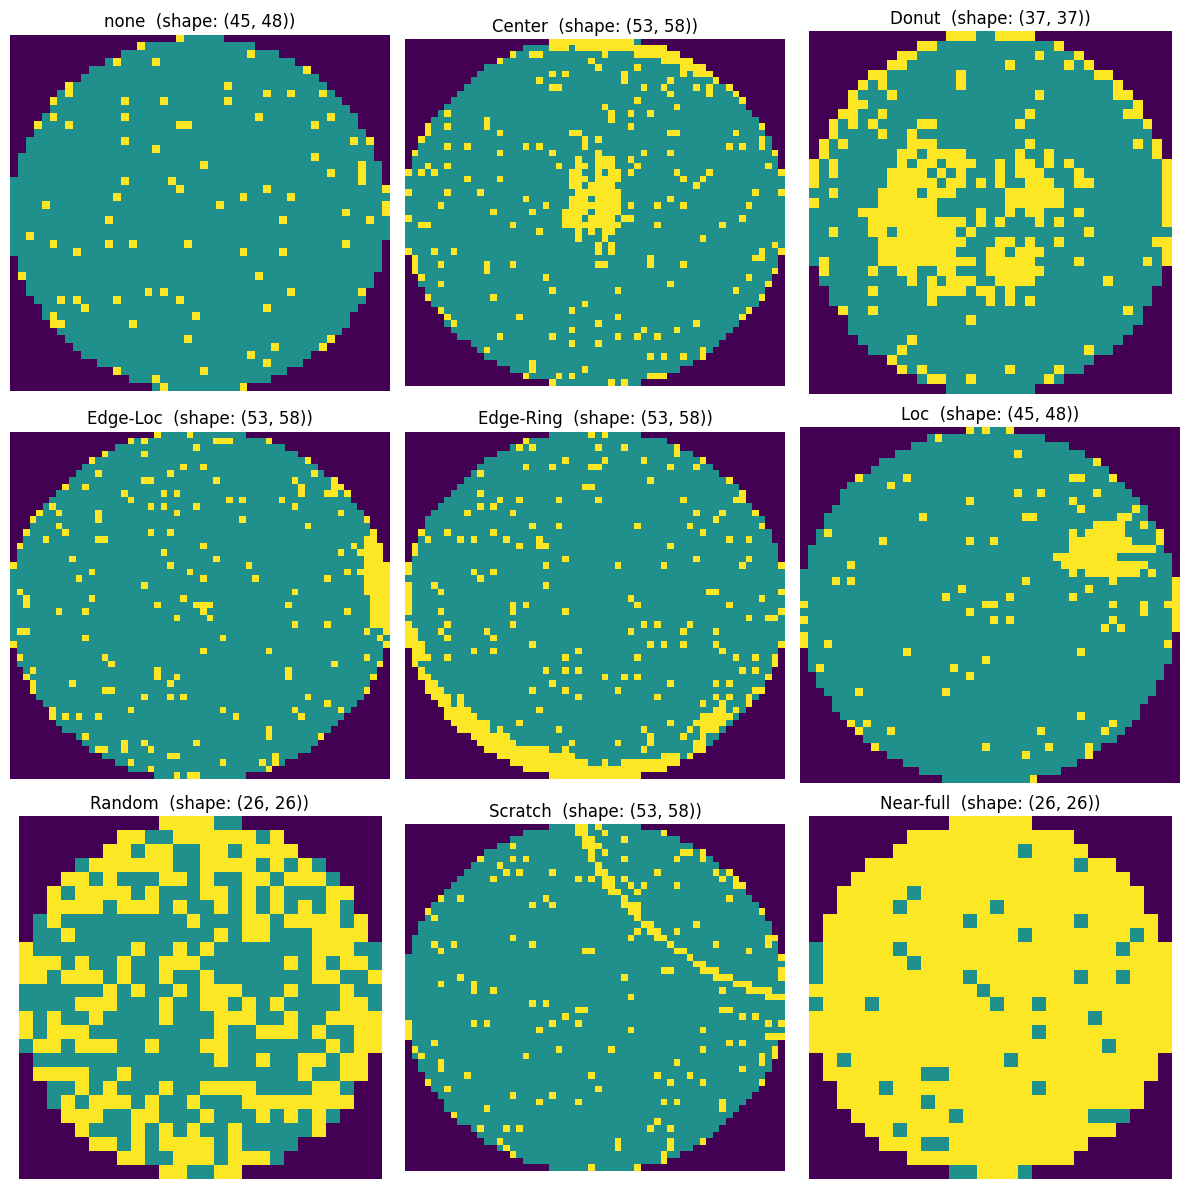

In [9]:
# Cell 8: Visualize one example wafer map per defect class
import matplotlib.pyplot as plt

labeled_df = df[df['failureType_clean'] != 'MISSING'].copy()
classes_to_show = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, cls in enumerate(classes_to_show):
    example = labeled_df[labeled_df['failureType_clean'] == cls].iloc[0]
    wafer = np.array(example['waferMap'])
    axes[i].imshow(wafer, cmap='viridis')
    axes[i].set_title(f"{cls}  (shape: {wafer.shape})")
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('wafer_examples.png', dpi=100)
plt.show()

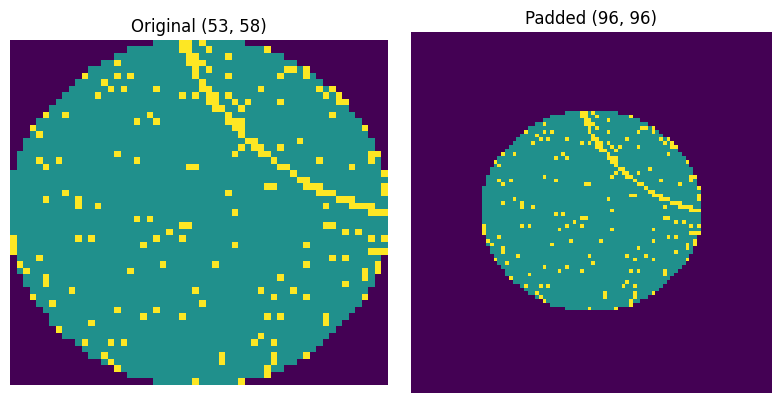

In [10]:
# Cell 9: Build and test the pad-to-square function
def pad_to_size(wafer_map, target=96):
    wafer_map = np.array(wafer_map)
    h, w = wafer_map.shape
    
    # If wafer exceeds target in either dimension, downsize first (rare, ~4.3% of cases)
    if h > target or w > target:
        from scipy.ndimage import zoom
        scale = target / max(h, w)
        wafer_map = zoom(wafer_map, scale, order=0)  # order=0 = nearest-neighbor, preserves category values
        h, w = wafer_map.shape
    
    pad_h = target - h
    pad_w = target - w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    
    return np.pad(wafer_map, ((top, bottom), (left, right)), mode='constant', constant_values=0)

# Test on one Scratch example (diagonal patterns are the most sensitive to distortion)
example = labeled_df[labeled_df['failureType_clean'] == 'Scratch'].iloc[0]
original = np.array(example['waferMap'])
padded = pad_to_size(original, target=96)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original, cmap='viridis')
axes[0].set_title(f"Original {original.shape}")
axes[0].axis('off')
axes[1].imshow(padded, cmap='viridis')
axes[1].set_title(f"Padded {padded.shape}")
axes[1].axis('off')
plt.tight_layout()
plt.savefig('padding_test.png', dpi=100)
plt.show()

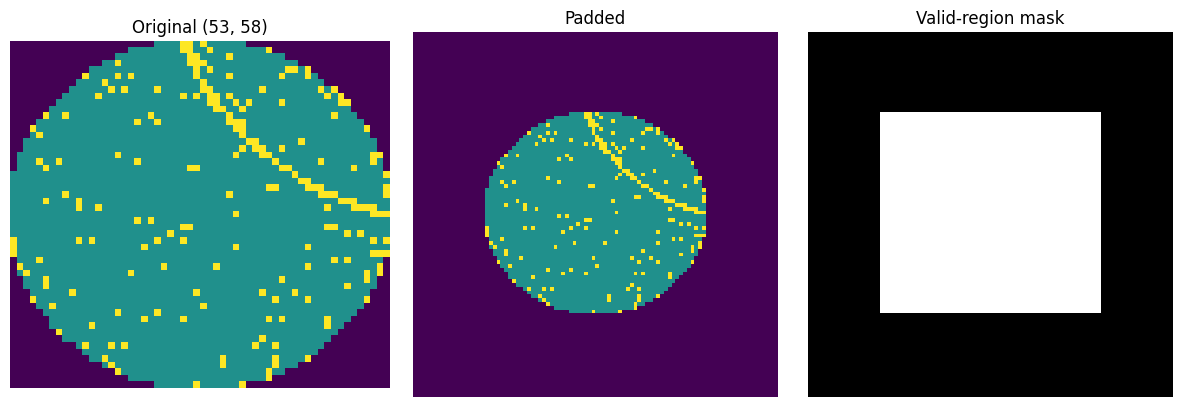

In [11]:
# Cell 10: Pad function that also returns a valid-region mask
def pad_to_size_with_mask(wafer_map, target=96):
    wafer_map = np.array(wafer_map)
    h, w = wafer_map.shape

    if h > target or w > target:
        from scipy.ndimage import zoom
        scale = target / max(h, w)
        wafer_map = zoom(wafer_map, scale, order=0)
        h, w = wafer_map.shape

    pad_h = target - h
    pad_w = target - w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2

    padded = np.pad(wafer_map, ((top, bottom), (left, right)), mode='constant', constant_values=0)

    # mask: 1 = real scanned wafer area, 0 = artificial padding we added
    mask = np.zeros((target, target), dtype=np.uint8)
    mask[top:top+h, left:left+w] = 1

    return padded, mask

# Quick test
example = labeled_df[labeled_df['failureType_clean'] == 'Scratch'].iloc[0]
original = np.array(example['waferMap'])
padded, mask = pad_to_size_with_mask(original, target=96)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original, cmap='viridis'); axes[0].set_title(f"Original {original.shape}"); axes[0].axis('off')
axes[1].imshow(padded, cmap='viridis'); axes[1].set_title("Padded"); axes[1].axis('off')
axes[2].imshow(mask, cmap='gray'); axes[2].set_title("Valid-region mask"); axes[2].axis('off')
plt.tight_layout()
plt.savefig('mask_test.png', dpi=100)
plt.show()

In [12]:
# Cell 11: Build stratified train/val/test split, holding out Near-full as the unknown class
from sklearn.model_selection import train_test_split

labeled_df = df[df['failureType_clean'] != 'MISSING'].copy()

# Separate out the held-out "unknown" class entirely
unknown_class = 'Near-full'
known_df = labeled_df[labeled_df['failureType_clean'] != unknown_class].copy()
unknown_df = labeled_df[labeled_df['failureType_clean'] == unknown_class].copy()

print(f"Known-class pool (used for train/val/test): {len(known_df)}")
print(f"Held-out unknown class ({unknown_class}): {len(unknown_df)}")
print()

# Stratified split: 70% train, 15% val, 15% test, on the KNOWN classes only
train_df, temp_df = train_test_split(
    known_df, test_size=0.30, stratify=known_df['failureType_clean'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['failureType_clean'], random_state=42
)

print(f"Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}")
print()
print("Class distribution in Train:")
print(train_df['failureType_clean'].value_counts())
print()
print("Class distribution in Val:")
print(val_df['failureType_clean'].value_counts())
print()
print("Class distribution in Test:")
print(test_df['failureType_clean'].value_counts())

Known-class pool (used for train/val/test): 172801
Held-out unknown class (Near-full): 149

Train: 120960   Val: 25920   Test: 25921

Class distribution in Train:
none         103201
Edge-Ring      6776
Edge-Loc       3632
Center         3006
Loc            2515
Scratch         835
Random          606
Donut           389
Name: failureType_clean, dtype: int64

Class distribution in Val:
none         22115
Edge-Ring     1452
Edge-Loc       778
Center         644
Loc            539
Scratch        179
Random         130
Donut           83
Name: failureType_clean, dtype: int64

Class distribution in Test:
none         22115
Edge-Ring     1452
Edge-Loc       779
Center         644
Loc            539
Scratch        179
Random         130
Donut           83
Name: failureType_clean, dtype: int64


In [13]:
# Cell 12: Prepare the self-supervised pretraining pool, and verify no overlap with labeled data
unlabeled_df = df[df['failureType_clean'] == 'MISSING'].copy()

print("Unlabeled (SSL pretraining pool):", len(unlabeled_df))
print()

# Sanity check: confirm no index overlap between unlabeled pool and labeled train/val/test
overlap_train = unlabeled_df.index.intersection(train_df.index)
overlap_val = unlabeled_df.index.intersection(val_df.index)
overlap_test = unlabeled_df.index.intersection(test_df.index)
overlap_unknown = unlabeled_df.index.intersection(unknown_df.index)

print("Overlap with train:", len(overlap_train))
print("Overlap with val:", len(overlap_val))
print("Overlap with test:", len(overlap_test))
print("Overlap with held-out unknown:", len(overlap_unknown))
print()

# Total sanity check: everything should sum back to 811,457
total = len(unlabeled_df) + len(train_df) + len(val_df) + len(test_df) + len(unknown_df)
print("Total accounted for:", total, " (should equal 811457)")

Unlabeled (SSL pretraining pool): 638507

Overlap with train: 0
Overlap with val: 0
Overlap with test: 0
Overlap with held-out unknown: 0

Total accounted for: 811457  (should equal 811457)


In [14]:
# Cell 14: Duplicate check
dup_count = df.duplicated(subset=['lotName', 'waferIndex']).sum()
print("Duplicate (lotName, waferIndex) pairs:", dup_count)

# Also check for fully identical wafer maps (different lot/index but same pattern - less likely but worth knowing)
print("\nUnique lots:", df['lotName'].nunique())
print("Total rows:", len(df))

Duplicate (lotName, waferIndex) pairs: 0

Unique lots: 46293
Total rows: 811457


In [15]:
# Cell 3 (bulletproof version): manual counting, no pandas reshape functions at all
labeled_df = df[df['failureType_clean'] != 'MISSING'].copy()

classes = sorted(labeled_df['failureType_clean'].unique())
splits = sorted(labeled_df['trainTestLabel_clean'].unique())

print(f"{'Class':<12}", end='')
for s in splits:
    print(f"{s:>12}", end='')
print()

for c in classes:
    print(f"{c:<12}", end='')
    for s in splits:
        count = ((labeled_df['failureType_clean'] == c) & (labeled_df['trainTestLabel_clean'] == s)).sum()
        print(f"{count:>12}", end='')
    print()

Class               Test    Training
Center               832        3462
Donut                146         409
Edge-Loc            2772        2417
Edge-Ring           1126        8554
Loc                 1973        1620
Near-full             95          54
Random               257         609
Scratch              693         500
none              110701       36730


In [16]:
# Save preprocessed splits to scratch, so training scripts can just load arrays directly
import numpy as np

def process_split(split_df, target=96):
    wafers = np.zeros((len(split_df), target, target), dtype=np.uint8)
    masks = np.zeros((len(split_df), target, target), dtype=np.uint8)
    labels = split_df['failureType_clean'].values

    for i, wm in enumerate(split_df['waferMap'].values):
        padded, mask = pad_to_size_with_mask(wm, target=target)
        wafers[i] = padded
        masks[i] = mask

    return wafers, masks, labels

save_dir = "/scratch/joshi.shreyas/wafer_processed"
import os
os.makedirs(save_dir, exist_ok=True)

print("Processing train...")
train_wafers, train_masks, train_labels = process_split(train_df)
np.savez_compressed(f"{save_dir}/train_data.npz", wafers=train_wafers, masks=train_masks, labels=train_labels)
print("Saved train:", train_wafers.shape)

print("Processing val...")
val_wafers, val_masks, val_labels = process_split(val_df)
np.savez_compressed(f"{save_dir}/val_data.npz", wafers=val_wafers, masks=val_masks, labels=val_labels)
print("Saved val:", val_wafers.shape)

print("Processing test...")
test_wafers, test_masks, test_labels = process_split(test_df)
np.savez_compressed(f"{save_dir}/test_data.npz", wafers=test_wafers, masks=test_masks, labels=test_labels)
print("Saved test:", test_wafers.shape)

print("Processing held-out unknown...")
unknown_wafers, unknown_masks, unknown_labels = process_split(unknown_df)
np.savez_compressed(f"{save_dir}/unknown_data.npz", wafers=unknown_wafers, masks=unknown_masks, labels=unknown_labels)
print("Saved unknown:", unknown_wafers.shape)

print("\nAll splits saved to:", save_dir)

Processing train...
Saved train: (120960, 96, 96)
Processing val...
Saved val: (25920, 96, 96)
Processing test...
Saved test: (25921, 96, 96)
Processing held-out unknown...
Saved unknown: (149, 96, 96)

All splits saved to: /scratch/joshi.shreyas/wafer_processed


In [17]:
# Process and save the unlabeled pool separately (this is the big one - 638,507 wafers)
print("Processing unlabeled pool (this will take a while)...")
unlabeled_wafers, unlabeled_masks, _ = process_split(unlabeled_df)

np.savez_compressed(f"{save_dir}/unlabeled_data.npz", wafers=unlabeled_wafers, masks=unlabeled_masks)
print("Saved unlabeled pool:", unlabeled_wafers.shape)

Processing unlabeled pool (this will take a while)...
Saved unlabeled pool: (638507, 96, 96)
